## Sample 1

In [23]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Band gap energy = 4.609 eV
Peak wavelength : 269.0 nm
Absorbance at this peak : 0.6646


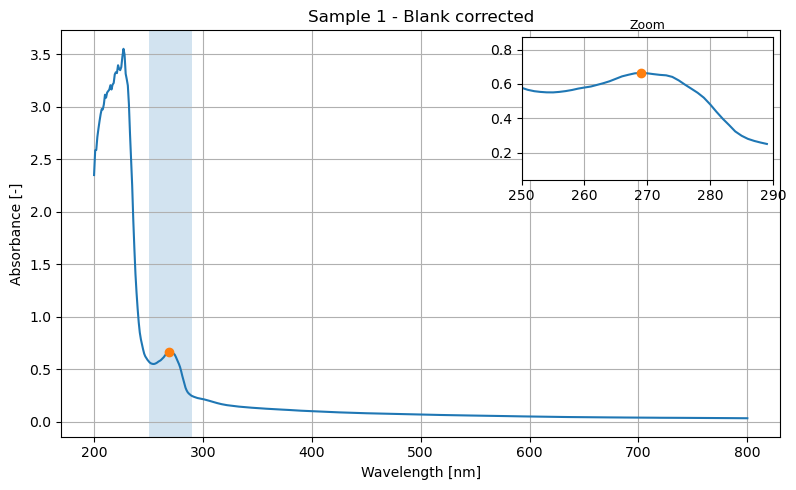

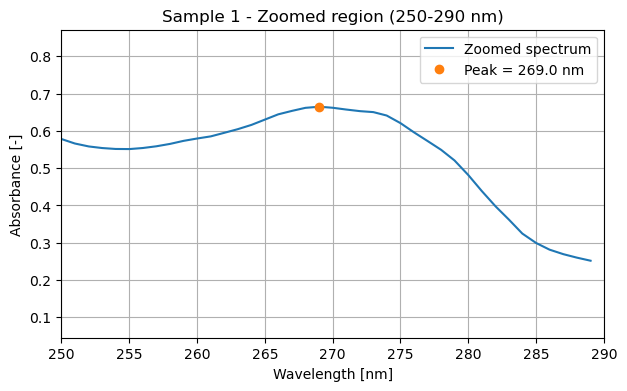

In [24]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1) Load files

sample1 = pd.read_csv('Sample1.csv')

# 2) Function to extract and average the 3 spectra
def extract_mean_spectrum(df):
    cols = df.columns.tolist()
    wavelengths = None
    spectra = []

    for i in range(0, len(cols) - 1, 2):
        wl = pd.to_numeric(df[cols[i]], errors='coerce')
        ab = pd.to_numeric(df[cols[i + 1]], errors='coerce')

        mask = (~wl.isna()) & (~ab.isna())
        wl = wl[mask]
        ab = ab[mask]

        if wavelengths is None:
            wavelengths = wl.values

        spectra.append(ab.values)

    spectra = np.array(spectra)
    mean_spec = np.mean(spectra, axis=0)

    return wavelengths, mean_spec


# 3) Compute mean spectra
wl_blank, mean_blank = extract_mean_spectrum(blank)
wl_sample, mean_sample = extract_mean_spectrum(sample1)


# 4) Interpolate blank if needed
if not np.array_equal(wl_blank, wl_sample):
    mean_blank_interp = np.interp(wl_sample, wl_blank, mean_blank)
else:
    mean_blank_interp = mean_blank

# 5) Corrected spectrum
corrected = mean_sample - mean_blank_interp


# 6) Define the wavelength range where the peak is searched
wl_min = 250
wl_max = 290

mask_peak = (wl_sample >= wl_min) & (wl_sample <= wl_max)

wl_peak_region = wl_sample[mask_peak]
abs_peak_region = corrected[mask_peak]

idx_local_max = np.argmax(abs_peak_region)

lambda_peak = wl_peak_region[idx_local_max]
absorbance_peak = abs_peak_region[idx_local_max]

Eg = 1240 / lambda_peak
print(f"Band gap energy = {Eg:.3f} eV")
print(f"Peak wavelength : {lambda_peak:.1f} nm")
print(f"Absorbance at this peak : {absorbance_peak:.4f}")

# 7) Main plot with inset zoom
fig, ax = plt.subplots(figsize=(8, 5))

# Main spectrum
ax.plot(wl_sample, corrected, label = 'Corrected spectrum')
ax.plot(lambda_peak, absorbance_peak, 'o', label = f'Peak = {lambda_peak:.1f} nm')

# Highlight the zoomed region on the main graph
ax.axvspan(wl_min, wl_max, alpha = 0.2)

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Absorbance [-]')
ax.set_title('Sample 1 - Blank corrected')
ax.grid()
ax.legend()

# Inset plot
ax_inset = inset_axes(ax, width="35%", height="35%", loc='upper right')
ax_inset.plot(wl_peak_region, abs_peak_region)
ax_inset.plot(lambda_peak, absorbance_peak, 'o')

ax_inset.set_title('Zoom', fontsize=9)
ax_inset.grid()

# Set x and y limits for inset
ax_inset.set_xlim(wl_min, wl_max)
y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
ax_inset.set_ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.tight_layout()
plt.show()


# 8) Separate zoomed plot
plt.figure(figsize=(7, 4))
plt.plot(wl_peak_region, abs_peak_region, label='Zoomed spectrum')
plt.plot(lambda_peak, absorbance_peak, 'o', label=f'Peak = {lambda_peak:.1f} nm')

plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorbance [-]')
plt.title(f'Sample 1 - Zoomed region ({wl_min}-{wl_max} nm)')
plt.xlim(wl_min, wl_max)

y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
plt.ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.grid()
plt.legend()
plt.show()

## Sample 2

Band gap energy = 2.230 eV
Peak wavelength : 556.0 nm
Absorbance at this peak : 0.2197


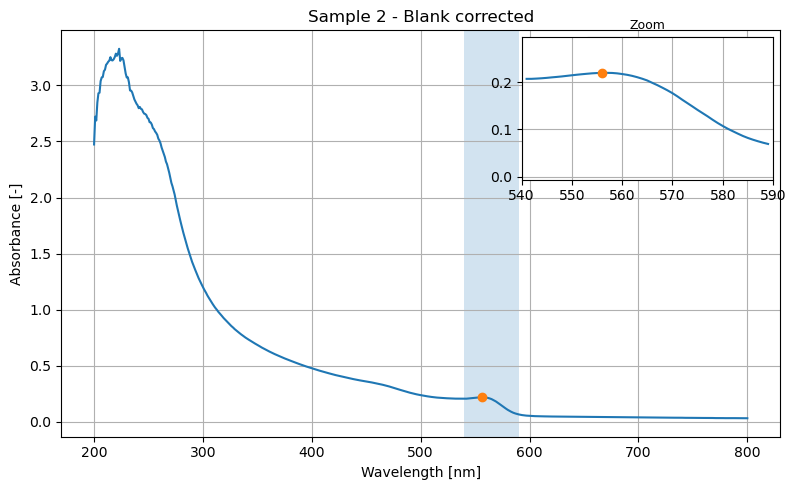

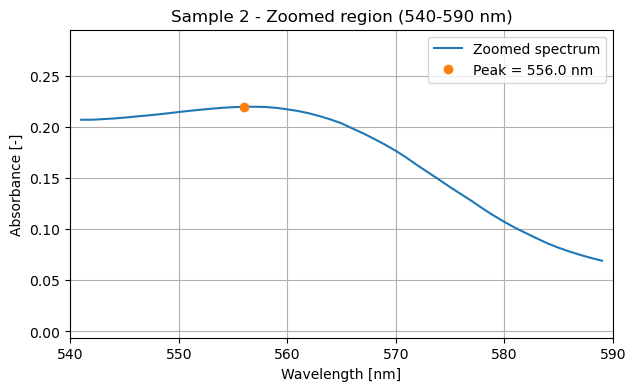

In [25]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1) Load files

sample2 = pd.read_csv('Sample2.csv')

# 2) Function to extract and average the 3 spectra
def extract_mean_spectrum(df):
    cols = df.columns.tolist()
    wavelengths = None
    spectra = []

    for i in range(0, len(cols) - 1, 2):
        wl = pd.to_numeric(df[cols[i]], errors='coerce')
        ab = pd.to_numeric(df[cols[i + 1]], errors='coerce')

        mask = (~wl.isna()) & (~ab.isna())
        wl = wl[mask]
        ab = ab[mask]

        if wavelengths is None:
            wavelengths = wl.values

        spectra.append(ab.values)

    spectra = np.array(spectra)
    mean_spec = np.mean(spectra, axis=0)

    return wavelengths, mean_spec


# 3) Compute mean spectra
wl_blank, mean_blank = extract_mean_spectrum(blank)
wl_sample, mean_sample = extract_mean_spectrum(sample2)


# 4) Interpolate blank if needed
if not np.array_equal(wl_blank, wl_sample):
    mean_blank_interp = np.interp(wl_sample, wl_blank, mean_blank)
else:
    mean_blank_interp = mean_blank

# 5) Corrected spectrum
corrected = mean_sample - mean_blank_interp


# 6) Define the wavelength range where the peak is searched
wl_min = 540
wl_max = 590

mask_peak = (wl_sample >= wl_min) & (wl_sample <= wl_max)

wl_peak_region = wl_sample[mask_peak]
abs_peak_region = corrected[mask_peak]

idx_local_max = np.argmax(abs_peak_region)

lambda_peak = wl_peak_region[idx_local_max]
absorbance_peak = abs_peak_region[idx_local_max]

Eg = 1240 / lambda_peak
print(f"Band gap energy = {Eg:.3f} eV")
print(f"Peak wavelength : {lambda_peak:.1f} nm")
print(f"Absorbance at this peak : {absorbance_peak:.4f}")

# 7) Main plot with inset zoom
fig, ax = plt.subplots(figsize=(8, 5))

# Main spectrum
ax.plot(wl_sample, corrected, label = 'Corrected spectrum')
ax.plot(lambda_peak, absorbance_peak, 'o', label = f'Peak = {lambda_peak:.1f} nm')

# Highlight the zoomed region on the main graph
ax.axvspan(wl_min, wl_max, alpha = 0.2)

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Absorbance [-]')
ax.set_title('Sample 2 - Blank corrected')
ax.grid()
ax.legend()

# Inset plot
ax_inset = inset_axes(ax, width="35%", height="35%", loc='upper right')
ax_inset.plot(wl_peak_region, abs_peak_region)
ax_inset.plot(lambda_peak, absorbance_peak, 'o')

ax_inset.set_title('Zoom', fontsize=9)
ax_inset.grid()

# Set x and y limits for inset
ax_inset.set_xlim(wl_min, wl_max)
y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
ax_inset.set_ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.tight_layout()
plt.show()


# 8) Separate zoomed plot
plt.figure(figsize=(7, 4))
plt.plot(wl_peak_region, abs_peak_region, label='Zoomed spectrum')
plt.plot(lambda_peak, absorbance_peak, 'o', label=f'Peak = {lambda_peak:.1f} nm')

plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorbance [-]')
plt.title(f'Sample 2 - Zoomed region ({wl_min}-{wl_max} nm)')
plt.xlim(wl_min, wl_max)

y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
plt.ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.grid()
plt.legend()
plt.show()

## Sample 3

Band gap energy = 2.412 eV
Peak wavelength : 514.0 nm
Absorbance at this peak : 0.1120


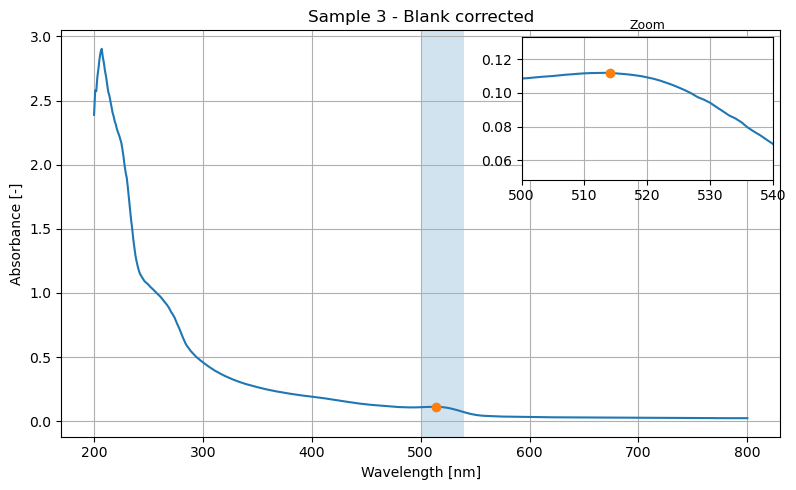

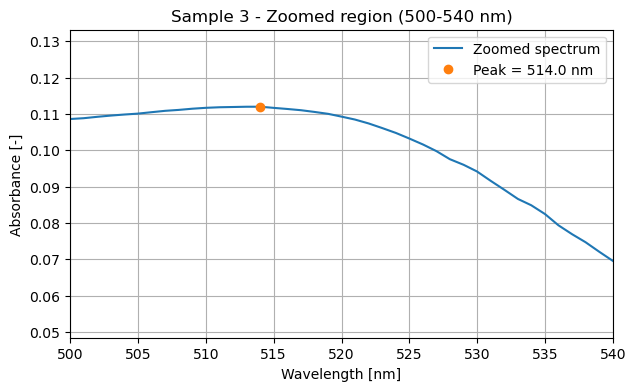

In [26]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1) Load files

sample3 = pd.read_csv('Sample3.csv')

# 2) Function to extract and average the 3 spectra
def extract_mean_spectrum(df):
    cols = df.columns.tolist()
    wavelengths = None
    spectra = []

    for i in range(0, len(cols) - 1, 2):
        wl = pd.to_numeric(df[cols[i]], errors='coerce')
        ab = pd.to_numeric(df[cols[i + 1]], errors='coerce')

        mask = (~wl.isna()) & (~ab.isna())
        wl = wl[mask]
        ab = ab[mask]

        if wavelengths is None:
            wavelengths = wl.values

        spectra.append(ab.values)

    spectra = np.array(spectra)
    mean_spec = np.mean(spectra, axis=0)

    return wavelengths, mean_spec


# 3) Compute mean spectra
wl_blank, mean_blank = extract_mean_spectrum(blank)
wl_sample, mean_sample = extract_mean_spectrum(sample3)


# 4) Interpolate blank if needed
if not np.array_equal(wl_blank, wl_sample):
    mean_blank_interp = np.interp(wl_sample, wl_blank, mean_blank)
else:
    mean_blank_interp = mean_blank

# 5) Corrected spectrum
corrected = mean_sample - mean_blank_interp


# 6) Define the wavelength range where the peak is searched
wl_min = 500
wl_max = 540

mask_peak = (wl_sample >= wl_min) & (wl_sample <= wl_max)

wl_peak_region = wl_sample[mask_peak]
abs_peak_region = corrected[mask_peak]

idx_local_max = np.argmax(abs_peak_region)

lambda_peak = wl_peak_region[idx_local_max]
absorbance_peak = abs_peak_region[idx_local_max]

Eg = 1240 / lambda_peak
print(f"Band gap energy = {Eg:.3f} eV")
print(f"Peak wavelength : {lambda_peak:.1f} nm")
print(f"Absorbance at this peak : {absorbance_peak:.4f}")

# 7) Main plot with inset zoom
fig, ax = plt.subplots(figsize=(8, 5))

# Main spectrum
ax.plot(wl_sample, corrected, label = 'Corrected spectrum')
ax.plot(lambda_peak, absorbance_peak, 'o', label = f'Peak = {lambda_peak:.1f} nm')

# Highlight the zoomed region on the main graph
ax.axvspan(wl_min, wl_max, alpha = 0.2)

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Absorbance [-]')
ax.set_title('Sample 3 - Blank corrected')
ax.grid()
ax.legend()

# Inset plot
ax_inset = inset_axes(ax, width="35%", height="35%", loc='upper right')
ax_inset.plot(wl_peak_region, abs_peak_region)
ax_inset.plot(lambda_peak, absorbance_peak, 'o')

ax_inset.set_title('Zoom', fontsize=9)
ax_inset.grid()

# Set x and y limits for inset
ax_inset.set_xlim(wl_min, wl_max)
y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
ax_inset.set_ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.tight_layout()
plt.show()


# 8) Separate zoomed plot
plt.figure(figsize=(7, 4))
plt.plot(wl_peak_region, abs_peak_region, label='Zoomed spectrum')
plt.plot(lambda_peak, absorbance_peak, 'o', label=f'Peak = {lambda_peak:.1f} nm')

plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorbance [-]')
plt.title(f'Sample 3 - Zoomed region ({wl_min}-{wl_max} nm)')
plt.xlim(wl_min, wl_max)

y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
plt.ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.grid()
plt.legend()
plt.show()

## Sample 4

Band gap energy = 2.195 eV
Chosen wavelength : 565.0 nm
Absorbance at this wavelength : 0.2135


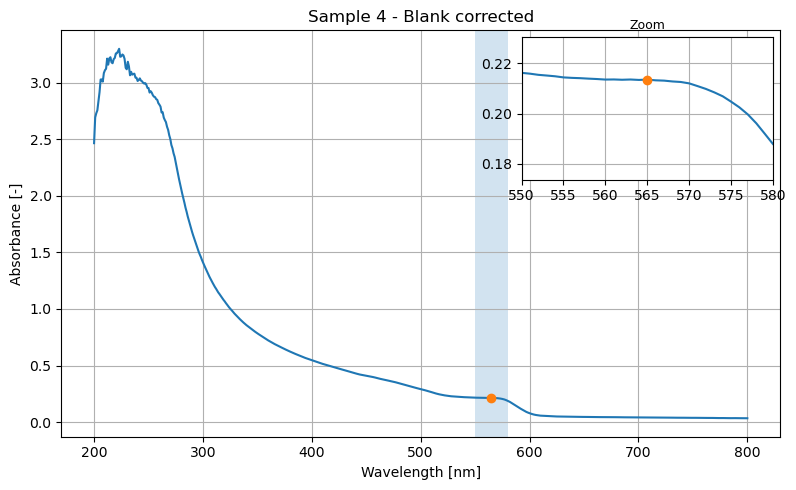

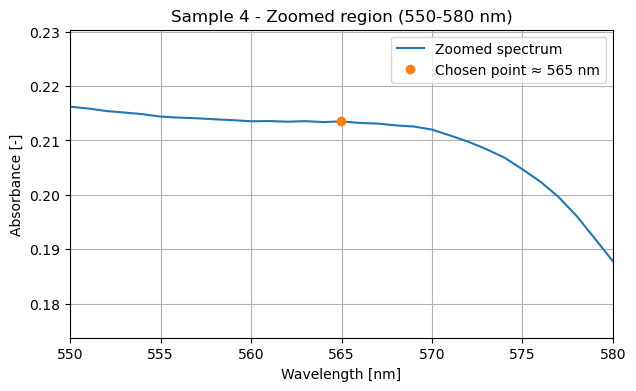

In [27]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1) Load files

sample4 = pd.read_csv('Sample4.csv')

# 2) Function to extract and average the 3 spectra
def extract_mean_spectrum(df):
    cols = df.columns.tolist()
    wavelengths = None
    spectra = []

    for i in range(0, len(cols) - 1, 2):
        wl = pd.to_numeric(df[cols[i]], errors='coerce')
        ab = pd.to_numeric(df[cols[i + 1]], errors='coerce')

        mask = (~wl.isna()) & (~ab.isna())
        wl = wl[mask]
        ab = ab[mask]

        if wavelengths is None:
            wavelengths = wl.values

        spectra.append(ab.values)

    spectra = np.array(spectra)
    mean_spec = np.mean(spectra, axis=0)

    return wavelengths, mean_spec


# 3) Compute mean spectra
wl_blank, mean_blank = extract_mean_spectrum(blank)
wl_sample, mean_sample = extract_mean_spectrum(sample4)


# 4) Interpolate blank if needed
if not np.array_equal(wl_blank, wl_sample):
    mean_blank_interp = np.interp(wl_sample, wl_blank, mean_blank)
else:
    mean_blank_interp = mean_blank

# 5) Corrected spectrum
corrected = mean_sample - mean_blank_interp


# 6) Choose a fixed wavelength manually
wl_min = 550
wl_max = 580

mask_peak = (wl_sample >= wl_min) & (wl_sample <= wl_max)
wl_peak_region = wl_sample[mask_peak]
abs_peak_region = corrected[mask_peak]

# cible
lambda_target = 565.0

idx_closest = np.argmin(np.abs(wl_peak_region - lambda_target))
lambda_peak = wl_peak_region[idx_closest]
absorbance_peak = abs_peak_region[idx_closest]

Eg = 1240 / lambda_target
print(f"Band gap energy = {Eg:.3f} eV")
print(f"Chosen wavelength : {lambda_peak:.1f} nm")
print(f"Absorbance at this wavelength : {absorbance_peak:.4f}")

# 7) Main plot with inset zoom
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(wl_sample, corrected, label='Corrected spectrum')
ax.plot(lambda_peak, absorbance_peak, 'o', markersize = 6,
        zorder=5, label=f'Chosen point ≈ 565 nm')

ax.axvspan(wl_min, wl_max, alpha=0.2)

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Absorbance [-]')
ax.set_title('Sample 4 - Blank corrected')
ax.grid()
ax.legend()

ax_inset = inset_axes(ax, width="35%", height="35%", loc='upper right')
ax_inset.plot(wl_peak_region, abs_peak_region)
ax_inset.plot(lambda_peak, absorbance_peak, 'o', markersize=6, zorder=5)

ax_inset.set_title('Zoom', fontsize=9)
ax_inset.grid()

ax_inset.set_xlim(wl_min, wl_max)
y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
ax_inset.set_ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.tight_layout()
plt.show()

# 8) Separate zoomed plot
plt.figure(figsize=(7, 4))
plt.plot(wl_peak_region, abs_peak_region, label='Zoomed spectrum')
plt.plot(lambda_peak, absorbance_peak, 'o', markersize=6,
         label=f'Chosen point ≈ 565 nm')

plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorbance [-]')
plt.title(f'Sample 4 - Zoomed region ({wl_min}-{wl_max} nm)')
plt.xlim(wl_min, wl_max)
plt.ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.grid()
plt.legend()
plt.show()



## Sample 5

Band gap energy = 2.340 eV
Peak wavelength : 530.0 nm
Absorbance at this peak : 0.1196


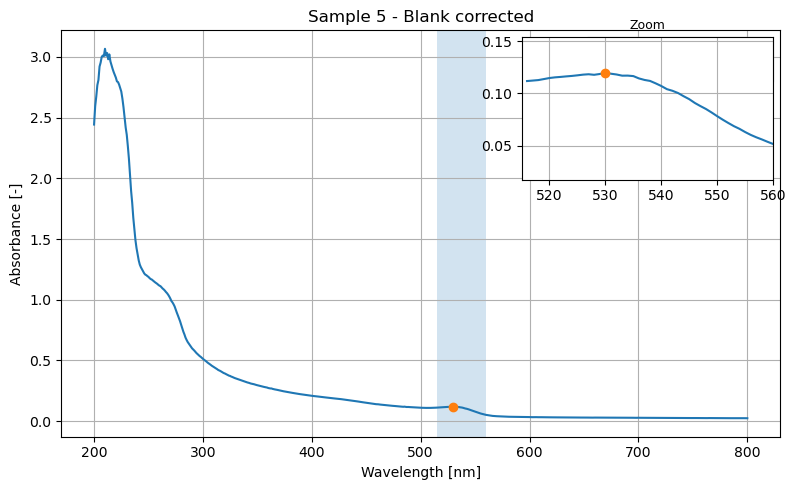

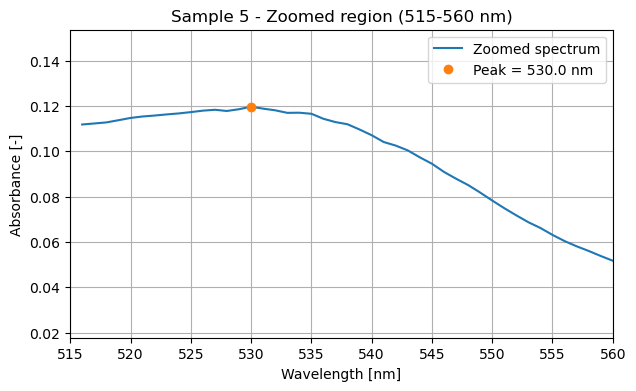

In [28]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# 1) Load files

sample5 = pd.read_csv('Sample5.csv')

# 2) Function to extract and average the 3 spectra
def extract_mean_spectrum(df):
    cols = df.columns.tolist()
    wavelengths = None
    spectra = []

    for i in range(0, len(cols) - 1, 2):
        wl = pd.to_numeric(df[cols[i]], errors='coerce')
        ab = pd.to_numeric(df[cols[i + 1]], errors='coerce')

        mask = (~wl.isna()) & (~ab.isna())
        wl = wl[mask]
        ab = ab[mask]

        if wavelengths is None:
            wavelengths = wl.values

        spectra.append(ab.values)

    spectra = np.array(spectra)
    mean_spec = np.mean(spectra, axis=0)

    return wavelengths, mean_spec


# 3) Compute mean spectra
wl_blank, mean_blank = extract_mean_spectrum(blank)
wl_sample, mean_sample = extract_mean_spectrum(sample5)


# 4) Interpolate blank if needed
if not np.array_equal(wl_blank, wl_sample):
    mean_blank_interp = np.interp(wl_sample, wl_blank, mean_blank)
else:
    mean_blank_interp = mean_blank

# 5) Corrected spectrum
corrected = mean_sample - mean_blank_interp


# 6) Define the wavelength range where the peak is searched
wl_min = 515
wl_max = 560

mask_peak = (wl_sample >= wl_min) & (wl_sample <= wl_max)

wl_peak_region = wl_sample[mask_peak]
abs_peak_region = corrected[mask_peak]

idx_local_max = np.argmax(abs_peak_region)

lambda_peak = wl_peak_region[idx_local_max]
absorbance_peak = abs_peak_region[idx_local_max]

Eg = 1240 / lambda_peak
print(f"Band gap energy = {Eg:.3f} eV")
print(f"Peak wavelength : {lambda_peak:.1f} nm")
print(f"Absorbance at this peak : {absorbance_peak:.4f}")

# 7) Main plot with inset zoom
fig, ax = plt.subplots(figsize=(8, 5))

# Main spectrum
ax.plot(wl_sample, corrected, label = 'Corrected spectrum')
ax.plot(lambda_peak, absorbance_peak, 'o', label = f'Peak = {lambda_peak:.1f} nm')

# Highlight the zoomed region on the main graph
ax.axvspan(wl_min, wl_max, alpha = 0.2)

ax.set_xlabel('Wavelength [nm]')
ax.set_ylabel('Absorbance [-]')
ax.set_title('Sample 5 - Blank corrected')
ax.grid()
ax.legend()

# Inset plot
ax_inset = inset_axes(ax, width="35%", height="35%", loc='upper right')
ax_inset.plot(wl_peak_region, abs_peak_region)
ax_inset.plot(lambda_peak, absorbance_peak, 'o')

ax_inset.set_title('Zoom', fontsize=9)
ax_inset.grid()

# Set x and y limits for inset
ax_inset.set_xlim(wl_min, wl_max)
y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
ax_inset.set_ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.tight_layout()
plt.show()


# 8) Separate zoomed plot
plt.figure(figsize=(7, 4))
plt.plot(wl_peak_region, abs_peak_region, label='Zoomed spectrum')
plt.plot(lambda_peak, absorbance_peak, 'o', label=f'Peak = {lambda_peak:.1f} nm')

plt.xlabel('Wavelength [nm]')
plt.ylabel('Absorbance [-]')
plt.title(f'Sample 5 - Zoomed region ({wl_min}-{wl_max} nm)')
plt.xlim(wl_min, wl_max)

y_margin = 0.5 * (abs_peak_region.max() - abs_peak_region.min() + 1e-12)
plt.ylim(abs_peak_region.min() - y_margin, abs_peak_region.max() + y_margin)

plt.grid()
plt.legend()
plt.show()

# Size (empirical formula)

In [29]:
def cdse_diameter(lambda_nm):
    D = (1.6122e-9 * lambda_nm**4
         - 2.6575e-6 * lambda_nm**3
         + 1.6242e-3 * lambda_nm**2
         - 0.4277 * lambda_nm
         + 41.57)
    return D

lambdas = {
    "Sample 1": 269,
    "Sample 2": 556,
    "Sample 3": 514,
    "Sample 4": 565,
    "Sample 5": 530
}

for sample, lam in lambdas.items():
    D = cdse_diameter(lam)
    print(f"{sample}: D = {D:.2f} nm")

Sample 1: D = 0.76 nm
Sample 2: D = 3.17 nm
Sample 3: D = 2.49 nm
Sample 4: D = 3.38 nm
Sample 5: D = 2.70 nm
